In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import matplotlib.pyplot as plt

from src.data.market_loader import MarketLoader

from src.curves.curve_snapshot import CurveSnapshot
from src.curves.bootstrap.bootstrap_engine import BootstrapCurveEngine
from src.curves.projection_curve import ProjectionCurve
from src.curves.zero_curve import ZeroCurve

from src.instruments.instrument_builder import InstrumentBuilder

from src.curves.simulator.hull_white import HullWhiteSimulator

In [2]:
# downloading market curves
market_loader = MarketLoader()
market_curves = market_loader.market_loader_pipeline()

# downloading swap curves
swap_loader = MarketLoader()
swap_curves = swap_loader.swap_loader_pipeline()

treasury curve dataset already downloaded..
sofr curve dataset already downloaded..
futures curve dataset already downloaded..
estr curve dataset already downloaded..
usd_ois curve dataset already downloaded..
eur_ois curve dataset already downloaded..


In [3]:
### create curve snapshots
# SOFR snapshot
sofr_df = market_curves['sofr']

latest_date = sofr_df.index[-1]
latest_sofr_curve = sofr_df.iloc[-1]

sofr_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'sofr',
    as_of_date = latest_date,
    curve_row = latest_sofr_curve
)

# Futures snapshot
future_df = market_curves['futures']
latest_futures_curve = future_df.iloc[-1]

futures_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'futures',
    as_of_date = latest_date,
    curve_row = latest_futures_curve
)

# OIS snapshot
ois_df = swap_curves['usd_ois']

latest_swap_date = ois_df.index[-1]
latest_swap_curve = ois_df.iloc[-1]

ois_snapshot = CurveSnapshot.snap_from_df_row(
    curve_name = 'usd_ois',
    as_of_date = latest_swap_date,
    curve_row = latest_swap_curve
)

In [4]:
### create instruments from curve snapshot
# deposits
deposit_instruments = InstrumentBuilder.build_deposit_instruments(snapshot = sofr_snapshot)

# futures
future_instruments = InstrumentBuilder.build_future_instruments(snapshot = futures_snapshot)

# ois
ois_instruments = InstrumentBuilder.build_ois_instruments(snapshot = ois_snapshot)

### discount, projection and zero curve builder
# bootstrapping engine for generating the discount curve
all_instruments = deposit_instruments + future_instruments + ois_instruments

engine = BootstrapCurveEngine()

discount_curve = engine.bootstrap(
    snapshot = sofr_snapshot,
    instruments = all_instruments
)

# projection curve
projection_curve = ProjectionCurve(discount_curve = discount_curve)

# zero curve
zero_curve = ZeroCurve(discount_curve = discount_curve)

In [5]:
### HW short-rate simulator engine
# short-rate
r0 = zero_curve.get_zero_rate(maturity = 0.25)

# HW engine
hw_engine = HullWhiteSimulator(
    r0 = r0,
    random_seed = 2 
)

# single path simulator
single_path = hw_engine.simulate_single_path(
    maturity = 10.0,
    steps_per_year = 12
)

print(f'Short-rate: {r0:.6f}')

single_path

Short-rate: 0.035845


,Time,ShortRate
0,0.000000,0.035845
1,0.083333,0.034642
2,0.166667,0.034489
3,0.250000,0.028334
4,0.333333,0.033132
...,...,...
117,9.750000,0.021522
118,9.833333,0.018960
119,9.916667,0.026463
120,10.000000,0.022288


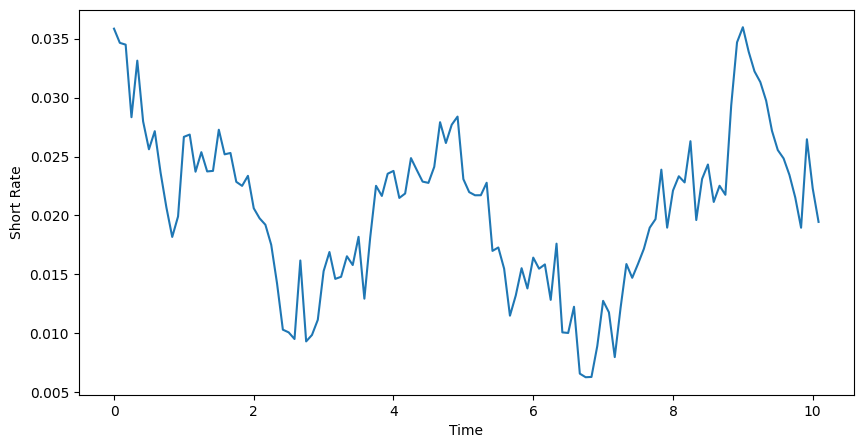

In [9]:
# plot hw short-rate simulation
plt.figure(figsize = (10, 5))

plt.plot(
    single_path['Time'],
    single_path['ShortRate']
)

plt.xlabel('Time')
plt.ylabel('Short Rate')
plt.show()